# Предсказание склонности к секретному действию

## Постановка задачи
Бинарная классификация: предсказать, совершит ли пользователь секретное (целевое) действие.

**Ключевые сложности:**
- Дисбаланс классов (~1.35% positive, соотношение ≈ 1 : 73)
- 1 367 анонимных числовых признаков, без текстовых полей
- Sentinel-значения (`-1.0` как маркер пропуска) в 184 признаках

**Метрика качества:** ROC-AUC
**Стратегия валидации:** 5-fold Stratified K-Fold (сохраняет долю позитивного класса в каждом фолде)  
**Baseline:** Logistic Regression  
**Финальное решение:** Stacking-ансамбль (LightGBM + CatBoost + XGBoost + FT-Transformer + MLP)

---


## Установка зависимостей

In [1]:
!pip install pandas numpy scikit-learn lightgbm catboost xgboost \
             torch optuna matplotlib seaborn scipy tqdm --quiet

import importlib
for pkg in ["pandas", "numpy", "sklearn", "lightgbm", "catboost", "xgboost", "torch", "optuna"]:
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg}: {m.__version__}")
    except Exception as e:
        print(f"{pkg}: НЕ УСТАНОВЛЕН — {e}")


pandas: 2.3.3
numpy: 2.4.6
sklearn: 1.6.1
lightgbm: 4.6.0
catboost: 1.2.10
xgboost: 3.2.0
torch: 2.10.0+cpu
optuna: 4.8.0


## 1. Импорты и глобальная конфигурация

In [2]:
import os, gc, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
DATA_DIR     = "/kaggle/input/competitions/vk-predict-cmc-hackathon"
ARTIFACT_DIR = "artifacts"
SUBMIT_DIR   = "submissions"
for d in [ARTIFACT_DIR, SUBMIT_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
N_FOLDS = 5
np.random.seed(RANDOM_STATE)

CONST_COLS = []
SENTINEL_VALUE  = -1.0
MISSING_IND_THR = 0.05
N_TOP_FEATURES  = 600 

DEVICE = __import__("torch").device(
    "cuda" if __import__("torch").cuda.is_available() else "cpu"
)
print(f"Device: {DEVICE}")

Device: cpu


## 2. Разведочный анализ данных (EDA)

In [4]:
print("Загрузка данных...")
train_raw = pd.read_csv(f"{DATA_DIR}/train.csv", dtype=np.float32)
test_raw  = pd.read_csv(f"{DATA_DIR}/test.csv",  dtype=np.float32)
print(f"train : {train_raw.shape}")
print(f"test  : {test_raw.shape}")

print("\nТипы данных в train:")
print(train_raw.dtypes.value_counts())
text_like = train_raw.select_dtypes(include=["object"]).columns.tolist()
print(f"Колонки типа object: {text_like}")


Загрузка данных...
train : (247972, 1369)
test  : (106274, 1368)

Типы данных в train:
float32    1369
Name: count, dtype: int64
Колонки типа object: []


In [5]:
feature_cols_check = [c for c in train_raw.columns if c.startswith("feature_")]
const_cols_found = [c for c in feature_cols_check if train_raw[c].nunique() == 1]
print(f"Найдено константных признаков: {len(const_cols_found)}")
print(f"Список: {const_cols_found}")

Найдено константных признаков: 7
Список: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_49', 'feature_1057', 'feature_1064']


Positive  :    3,346  (1.349%)
Negative  :  244,626  (98.651%)
Дисбаланс : 1 : 73


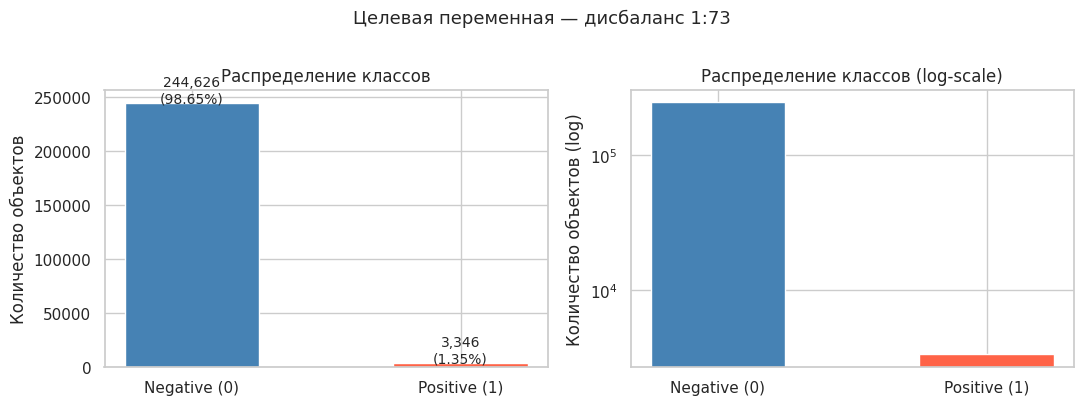

In [6]:
target = train_raw["target"]
pos = int(target.sum())
neg = int((target == 0).sum())
print(f"Positive  : {pos:>8,}  ({pos/len(target):.3%})")
print(f"Negative  : {neg:>8,}  ({neg/len(target):.3%})")
print(f"Дисбаланс : 1 : {neg/pos:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["Negative (0)", "Positive (1)"], [neg, pos],
            color=["steelblue", "tomato"], width=0.5)
for bar, val, pct in zip(axes[0].patches, [neg, pos],
                          [neg/len(target), pos/len(target)]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + len(target)*0.002,
                 f"{val:,}\n({pct:.2%})", ha="center", fontsize=10)
axes[0].set_title("Распределение классов")
axes[0].set_ylabel("Количество объектов")

axes[1].bar(["Negative (0)", "Positive (1)"], [neg, pos],
            color=["steelblue", "tomato"], width=0.5)
axes[1].set_yscale("log")
axes[1].set_title("Распределение классов (log-scale)")
axes[1].set_ylabel("Количество объектов (log)")

plt.suptitle("Целевая переменная — дисбаланс 1:73", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [6]:
feature_cols = [c for c in train_raw.columns if c.startswith("feature_")]
print(f"Всего feature_*: {len(feature_cols)}")

RANGES = [(0,10),(10,50),(50,200),(200,500),(500,800),(800,1000),(1000,1100),(1100,1200),(1200,1366)]
rows = []
for s, e in RANGES:
    cols = [f"feature_{i}" for i in range(s, e) if f"feature_{i}" in train_raw.columns]
    if not cols:
        continue
    blk = train_raw[cols]
    rows.append({
        "Блок": f"feature_{s}–{e}",
        "Кол-во": len(cols),
        "Константных": sum(blk[c].nunique() == 1 for c in cols),
        "Со sentinel(-1)": sum((blk[c] == -1).any() for c in cols),
        "Бинарных": sum(
            (blk[c].nunique() <= 2) or
            (blk[c].nunique() == 3 and set(blk[c].dropna().unique().astype(int)) == {-1, 0, 1})
            for c in cols
        ),
        "min": round(blk.min().min(), 2),
        "max": round(blk.max().max(), 2),
    })

block_df = pd.DataFrame(rows)
display(block_df.style.background_gradient(cmap="Blues", subset=["Кол-во", "Со sentinel(-1)"]))


Всего feature_*: 1367


,Блок,Кол-во,Константных,Со sentinel(-1),Бинарных,min,max
0,feature_0–10,10,4,0,4,0.000000,33.000000
1,feature_10–50,40,1,0,1,0.000000,14.960000
2,feature_50–200,150,0,0,17,0.000000,1591776.000000
3,feature_200–500,300,0,0,28,0.000000,1337320.000000
4,feature_500–800,300,0,0,10,0.000000,30212746.000000
5,feature_800–1000,200,0,0,2,0.000000,30220726.000000
6,feature_1000–1100,100,2,4,8,-1.000000,29684480.000000
7,feature_1100–1200,100,0,20,31,-1.000000,186464.000000
8,feature_1200–1366,166,0,160,166,-1.000000,1.000000


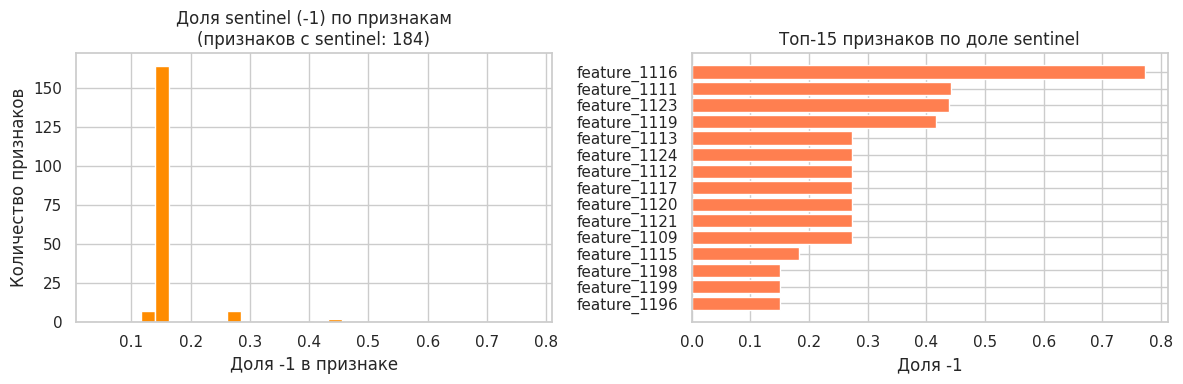

Топ-10 признаков по доле sentinel:
feature_1116    0.772668
feature_1111    0.441360
feature_1123    0.438368
feature_1119    0.416341
feature_1113    0.273345
feature_1124    0.273236
feature_1112    0.273236
feature_1117    0.273236
feature_1120    0.272720
feature_1121    0.272720


In [8]:
sentinel_cols = [c for c in feature_cols if (train_raw[c] == -1).any()]
sentinel_pct  = pd.Series({c: (train_raw[c] == -1).mean() for c in sentinel_cols})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sentinel_pct.values, bins=30, color="darkorange", edgecolor="white")
axes[0].set_title(f"Доля sentinel (-1) по признакам\n(признаков с sentinel: {len(sentinel_cols)})")
axes[0].set_xlabel("Доля -1 в признаке")
axes[0].set_ylabel("Количество признаков")

top_sent = sentinel_pct.sort_values(ascending=False).head(15)
axes[1].barh(top_sent.index[::-1], top_sent.values[::-1], color="coral")
axes[1].set_title("Топ-15 признаков по доле sentinel")
axes[1].set_xlabel("Доля -1")
plt.tight_layout()
plt.show()

print("Топ-10 признаков по доле sentinel:")
print(top_sent.head(10).to_string())


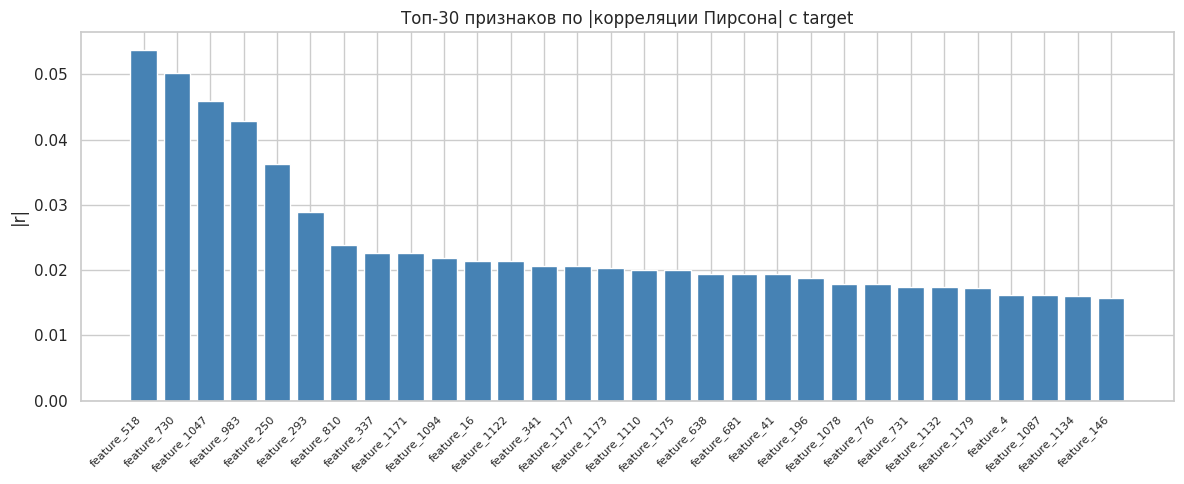

Топ-15 по корреляции с target:
feature_518     0.053778
feature_730     0.050209
feature_1047    0.045887
feature_983     0.042862
feature_250     0.036323
feature_293     0.028957
feature_810     0.023891
feature_337     0.022678
feature_1171    0.022583
feature_1094    0.021798
feature_16      0.021458
feature_1122    0.021362
feature_341     0.020568
feature_1177    0.020557
feature_1173    0.020323

Максимальная |корреляция|: 0.0538


1276

In [9]:
sample = train_raw.sample(min(25_000, len(train_raw)), random_state=RANDOM_STATE)
corrs  = sample[feature_cols].corrwith(sample["target"]).abs().sort_values(ascending=False)
top30  = corrs.head(30)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top30)), top30.values, color="steelblue")
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30.index, rotation=45, ha="right", fontsize=8)
ax.set_title("Топ-30 признаков по |корреляции Пирсона| с target")
ax.set_ylabel("|r|")
plt.tight_layout()
plt.show()

print("Топ-15 по корреляции с target:")
print(top30.head(15).to_string())
print(f"\nМаксимальная |корреляция|: {top30.iloc[0]:.4f}")

del sample
gc.collect()

## 3. Предобработка данных

In [10]:
def replace_sentinel(df, cols):
    df = df.copy()
    df[cols] = df[cols].replace(SENTINEL_VALUE, np.nan)
    return df

def add_missing_indicators(df, sentinel_cols, thr=MISSING_IND_THR):
    na_pct = df[sentinel_cols].isnull().mean()
    high_na = na_pct[na_pct > thr].index.tolist()
    for col in high_na:
        df[f"{col}_missing"] = df[col].isnull().astype(np.float32)
    print(f"  Добавлено missing-indicators: {len(high_na)}")
    return df

print(" Удаление константных признаков...")
CONST_COLS = const_cols_found
print(f"  Удаляем {len(CONST_COLS)} константных признаков: {CONST_COLS}")
train = train_raw.copy()
test  = test_raw.copy()
train.drop(columns=CONST_COLS, inplace=True, errors="ignore")

print(" Разделение X / y...")
y_raw  = train["target"].values.astype(np.float32)
X_raw  = train.drop(columns=["index", "target"])
Xt_raw = test.drop(columns=["index"])

sentinel_cols = [c for c in X_raw.columns if (X_raw[c] == SENTINEL_VALUE).any()]
print(f"  Признаков с sentinel: {len(sentinel_cols)}")

print(" Замена sentinel -> NaN + missing indicators...")
X_raw  = replace_sentinel(X_raw, sentinel_cols)
Xt_raw = replace_sentinel(Xt_raw, [c for c in sentinel_cols if c in Xt_raw.columns])
X_raw  = add_missing_indicators(X_raw, sentinel_cols)
Xt_raw = add_missing_indicators(Xt_raw, [c for c in sentinel_cols if c in Xt_raw.columns])

for col in X_raw.columns:
    if col not in Xt_raw.columns:
        Xt_raw[col] = 0.0
Xt_raw = Xt_raw[X_raw.columns]
print(f"  Признаков после расширения: {X_raw.shape[1]}")


 Удаление константных признаков...
  Удаляем 7 константных признаков: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_49', 'feature_1057', 'feature_1064']
 Разделение X / y...
  Признаков с sentinel: 184
 Замена sentinel -> NaN + missing indicators...
  Добавлено missing-indicators: 183
  Добавлено missing-indicators: 183
  Признаков после расширения: 1543


 Feature selection (LightGBM importance на 50k сэмпле)...
  Выбрано: 600 из 1543 признаков


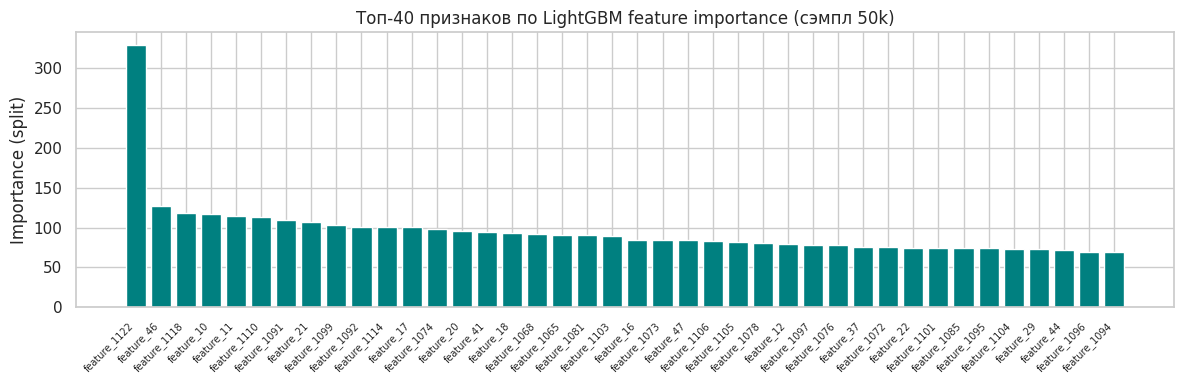

In [10]:
import lightgbm as lgb

print(" Feature selection (LightGBM importance на 50k сэмпле)...")
rng = np.random.RandomState(RANDOM_STATE)
idx_s = rng.choice(len(X_raw), size=min(50_000, len(X_raw)), replace=False)
Xs = X_raw.iloc[idx_s].values.astype(np.float32)
ys = y_raw[idx_s]

pos_s = int(ys.sum()); neg_s = int((ys == 0).sum())
fs_model = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=63, learning_rate=0.1,
    scale_pos_weight=neg_s/pos_s, feature_fraction=0.5,
    n_jobs=-1, verbose=-1, random_state=RANDOM_STATE, max_bin=63,
)
fs_model.fit(Xs, ys)
fi = pd.Series(fs_model.feature_importances_, index=X_raw.columns)
top_features = fi.sort_values(ascending=False).head(N_TOP_FEATURES).index.tolist()
print(f"  Выбрано: {len(top_features)} из {len(fi)} признаков")
del Xs, ys, fs_model
gc.collect()

fig, ax = plt.subplots(figsize=(12, 4))
top_plot = fi.sort_values(ascending=False).head(40)
ax.bar(range(40), top_plot.values, color="teal")
ax.set_xticks(range(40)); ax.set_xticklabels(top_plot.index, rotation=45, ha="right", fontsize=7)
ax.set_title("Топ-40 признаков по LightGBM feature importance (сэмпл 50k)")
ax.set_ylabel("Importance (split)")
plt.tight_layout(); plt.show()


In [11]:
print(" Сохранение артефактов...")
X      = X_raw[top_features].astype(np.float32)
X_test = Xt_raw[top_features].astype(np.float32)

X.to_pickle(f"{ARTIFACT_DIR}/X_train.pkl")
X_test.to_pickle(f"{ARTIFACT_DIR}/X_test.pkl")
pd.Series(y_raw).to_pickle(f"{ARTIFACT_DIR}/y_train.pkl")
np.save(f"{ARTIFACT_DIR}/top_features.npy", np.array(top_features))

y = y_raw
pos = int(y.sum()); neg = int((y == 0).sum())
scale_pos_weight = neg / pos

meta = dict(
    n_train=len(X), n_test=len(X_test),
    n_features_raw=X_raw.shape[1], n_features_selected=len(top_features),
    sentinel_cols=sentinel_cols, top_features=top_features,
    positive_rate=float(y.mean()), scale_pos_weight=scale_pos_weight,
)
with open(f"{ARTIFACT_DIR}/meta.pkl", "wb") as f:
    pickle.dump(meta, f)

print(f"  X_train : {X.shape},  {X.memory_usage().sum()/1e6:.0f} MB")
print(f"  X_test  : {X_test.shape}")
print(f"  Positive rate    : {y.mean():.4%}")
print(f"  scale_pos_weight : {scale_pos_weight:.1f}")
del train_raw, test_raw, X_raw, Xt_raw
gc.collect()

 Сохранение артефактов...
  X_train : (247972, 600),  595 MB
  X_test  : (106274, 600)
  Positive rate    : 1.3493%
  scale_pos_weight : 73.1


6688

## 4. Вспомогательные функции

In [12]:
MODEL_RESULTS = {}

def register(name, oof, test_pred, y):
    """Регистрирует результат модели в общем реестре и сохраняет на диск."""
    auc = roc_auc_score(y, oof)
    MODEL_RESULTS[name] = {"oof": oof, "test": test_pred, "auc": auc}
    print(f"  [{name}] OOF AUC = {auc:.5f}")
    safe = name.lower().replace(" ", "_").replace("-", "_")
    np.save(f"{ARTIFACT_DIR}/oof_{safe}.npy", oof)
    np.save(f"{ARTIFACT_DIR}/test_{safe}.npy", test_pred)

def run_cv_sklearn(name, model_fn, X, y, X_test, n_folds=N_FOLDS):
    """Универсальная 5-fold CV для sklearn-совместимых моделей."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X)); test_preds = np.zeros(len(X_test)); scores = []

    imp = SimpleImputer(strategy="median")
    X_imp  = imp.fit_transform(X.values if hasattr(X, "values") else X)
    Xt_imp = imp.transform(X_test.values if hasattr(X_test, "values") else X_test)

    for fold, (tr, val) in enumerate(skf.split(X_imp, y)):
        m = model_fn()
        m.fit(X_imp[tr], y[tr])
        vp = m.predict_proba(X_imp[val])[:, 1]
        oof[val] = vp
        test_preds += m.predict_proba(Xt_imp)[:, 1] / n_folds
        sc = roc_auc_score(y[val], vp)
        scores.append(sc)
        print(f"    Fold {fold+1}: AUC={sc:.5f}")
        gc.collect()

    print(f"  Mean: {np.mean(scores):.5f} +- {np.std(scores):.5f}")
    register(name, oof, test_preds, y)
    return oof, test_preds

def run_cv_lgb(X, y, X_test, params, n_folds=N_FOLDS, early_stop=50):
    """5-fold CV для LightGBM."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X)); test_preds = np.zeros(len(X_test)); scores = []
    fi_sum = np.zeros(X.shape[1])
    Xv = X.values; Xtv = X_test.values

    for fold, (tr, val) in enumerate(skf.split(Xv, y)):
        m = lgb.LGBMClassifier(**params)
        m.fit(Xv[tr], y[tr], eval_set=[(Xv[val], y[val])],
              callbacks=[lgb.early_stopping(early_stop, verbose=False), lgb.log_evaluation(100)])
        vp = m.predict_proba(Xv[val])[:, 1]
        oof[val] = vp
        test_preds += m.predict_proba(Xtv)[:, 1] / n_folds
        sc = roc_auc_score(y[val], vp)
        scores.append(sc); fi_sum += m.feature_importances_ / n_folds
        print(f"    Fold {fold+1}: AUC={sc:.5f}, iters={m.best_iteration_}")
        gc.collect()

    print(f"  Mean: {np.mean(scores):.5f} +- {np.std(scores):.5f}")
    fi_df = pd.DataFrame({"feature": list(X.columns), "importance": fi_sum}) \
              .sort_values("importance", ascending=False)
    fi_df.to_csv(f"{ARTIFACT_DIR}/lgb_fi.csv", index=False)
    register("LightGBM", oof, test_preds, y)
    return oof, test_preds

def run_cv_cat(X, y, X_test, params, n_folds=N_FOLDS, register_as="CatBoost"):
    """5-fold CV для CatBoost."""
    from catboost import CatBoostClassifier, Pool
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X)); test_preds = np.zeros(len(X_test)); scores = []
    fn = list(X.columns)
    Xa = X.values.astype(np.float32); Xta = X_test.values.astype(np.float32)

    for fold, (tr, val) in enumerate(skf.split(Xa, y)):
        m = CatBoostClassifier(**params)
        m.fit(Pool(Xa[tr], y[tr], feature_names=fn),
              eval_set=Pool(Xa[val], y[val], feature_names=fn), use_best_model=True)
        vp = m.predict_proba(Xa[val])[:, 1]
        oof[val] = vp
        test_preds += m.predict_proba(Xta)[:, 1] / n_folds
        sc = roc_auc_score(y[val], vp)
        scores.append(sc)
        print(f"    Fold {fold+1}: AUC={sc:.5f}, iters={m.best_iteration_}")
        gc.collect()

    print(f"  Mean: {np.mean(scores):.5f} +- {np.std(scores):.5f}")
    register(register_as, oof, test_preds, y)
    return oof, test_preds

def run_cv_xgb(X, y, X_test, params, n_folds=N_FOLDS, register_as="XGBoost"):
    """5-fold CV для XGBoost."""
    import xgboost as xgb
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X)); test_preds = np.zeros(len(X_test)); scores = []
    Xv = X.values; Xtv = X_test.values

    for fold, (tr, val) in enumerate(skf.split(Xv, y)):
        m = xgb.XGBClassifier(**params, early_stopping_rounds=50)
        m.fit(Xv[tr], y[tr], eval_set=[(Xv[val], y[val])], verbose=False)
        vp = m.predict_proba(Xv[val])[:, 1]
        oof[val] = vp
        test_preds += m.predict_proba(Xtv)[:, 1] / n_folds
        sc = roc_auc_score(y[val], vp)
        scores.append(sc)
        print(f"    Fold {fold+1}: AUC={sc:.5f}, best_iter={m.best_iteration}")
        gc.collect()

    print(f"  Mean: {np.mean(scores):.5f} +- {np.std(scores):.5f}")
    register(register_as, oof, test_preds, y)
    return oof, test_preds


## 5. Загрузка подготовленных данных

In [13]:
X      = pd.read_pickle(f"{ARTIFACT_DIR}/X_train.pkl")
y      = pd.read_pickle(f"{ARTIFACT_DIR}/y_train.pkl").values
X_test = pd.read_pickle(f"{ARTIFACT_DIR}/X_test.pkl")
with open(f"{ARTIFACT_DIR}/meta.pkl", "rb") as f:
    meta = pickle.load(f)

scale_pos_weight = meta["scale_pos_weight"]
print(f"X_train : {X.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Positive rate    : {y.mean():.4%}")
print(f"scale_pos_weight : {scale_pos_weight:.1f}")


X_train : (247972, 600)
X_test  : (106274, 600)
Positive rate    : 1.3493%
scale_pos_weight : 73.1


## 6. Baseline: Logistic Regression

In [14]:
print("=" * 50); print("Logistic Regression (baseline)"); print("=" * 50)

def make_logreg():
    return LogisticRegression(C=0.1, class_weight="balanced", solver="saga",
                              max_iter=300, n_jobs=-1, random_state=RANDOM_STATE)

oof_lr, test_lr = run_cv_sklearn("LogReg", make_logreg, X, y, X_test)
BASELINE_AUC = MODEL_RESULTS["LogReg"]["auc"]
print(f"\nBASELINE_AUC = {BASELINE_AUC:.5f}")


Logistic Regression (baseline)
    Fold 1: AUC=0.55412
    Fold 2: AUC=0.57370
    Fold 3: AUC=0.53948
    Fold 4: AUC=0.53722
    Fold 5: AUC=0.53328
  Mean: 0.54756 +- 0.01485
  [LogReg] OOF AUC = 0.54313

BASELINE_AUC = 0.54313


## 7. Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 50); print("Random Forest"); print("=" * 50)

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=50, max_features=0.3,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
    )

oof_rf, test_rf = run_cv_sklearn("RandomForest", make_rf, X, y, X_test)


Random Forest
    Fold 1: AUC=0.65131
    Fold 2: AUC=0.66224
    Fold 3: AUC=0.63129
    Fold 4: AUC=0.64228
    Fold 5: AUC=0.63505
  Mean: 0.64443 +- 0.01122
  [RandomForest] OOF AUC = 0.64406


## 8. LightGBM

In [16]:
print("=" * 50); print("LightGBM"); print("=" * 50)

LGB_PARAMS = {
    "objective": "binary", "metric": "auc", "boosting_type": "gbdt",
    "n_estimators": 1000, "learning_rate": 0.06,
    "num_leaves": 127, "max_depth": 8, "min_child_samples": 100,
    "feature_fraction": 0.6, "bagging_fraction": 0.85, "bagging_freq": 5,
    "lambda_l1": 0.05, "lambda_l2": 0.05,
    "scale_pos_weight": scale_pos_weight,
    "n_jobs": -1, "verbose": -1, "random_state": RANDOM_STATE, "max_bin": 127,
}

oof_lgb, test_lgb = run_cv_lgb(X, y, X_test, LGB_PARAMS)


LightGBM
[100]	valid_0's auc: 0.614647
[200]	valid_0's auc: 0.625308
[300]	valid_0's auc: 0.62923
    Fold 1: AUC=0.63103, iters=341
[100]	valid_0's auc: 0.637729
[200]	valid_0's auc: 0.643455
    Fold 2: AUC=0.64528, iters=223
[100]	valid_0's auc: 0.620544
    Fold 3: AUC=0.62364, iters=116
[100]	valid_0's auc: 0.627921
[200]	valid_0's auc: 0.629923
    Fold 4: AUC=0.63168, iters=185
[100]	valid_0's auc: 0.629015
    Fold 5: AUC=0.63292, iters=147
  Mean: 0.63291 +- 0.00699
  [LightGBM] OOF AUC = 0.63027


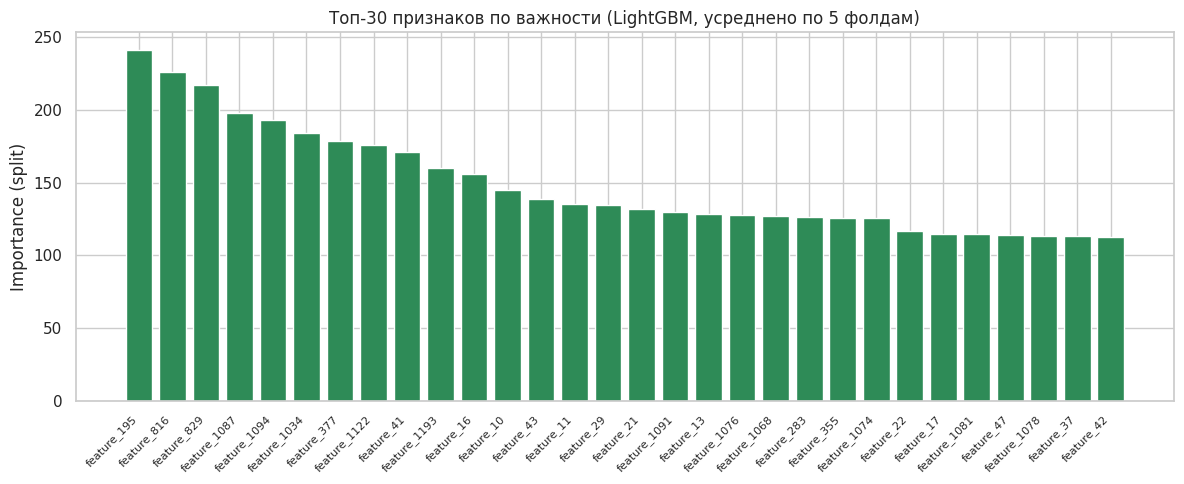

In [17]:
fi_lgb = pd.read_csv(f"{ARTIFACT_DIR}/lgb_fi.csv").head(30)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(fi_lgb)), fi_lgb["importance"].values, color="seagreen")
ax.set_xticks(range(len(fi_lgb)))
ax.set_xticklabels(fi_lgb["feature"].values, rotation=45, ha="right", fontsize=8)
ax.set_title("Топ-30 признаков по важности (LightGBM, усреднено по 5 фолдам)")
ax.set_ylabel("Importance (split)")
plt.tight_layout(); plt.show()


## 9. CatBoost (с подбором гиперпараметров через Optuna)

In [18]:
import optuna

print("=" * 50); print("CatBoost: Optuna-тюнинг (30 trials, 3-fold)"); print("=" * 50)

N_TRIALS_OPTUNA = 30

def objective_cat(trial):
    from catboost import CatBoostClassifier, Pool
    params = {
        "iterations": 500,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 300),
        "subsample": trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.3, 0.9),
        "eval_metric": "AUC", "loss_function": "Logloss",
        "auto_class_weights": "Balanced", "random_seed": RANDOM_STATE,
        "verbose": 0, "task_type": "CPU", "early_stopping_rounds": 30,
    }
    skf_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    Xv = X.values.astype(np.float32)
    scores = []
    for tr, val in skf_tune.split(Xv, y):
        m = CatBoostClassifier(**params)
        m.fit(Pool(Xv[tr], y[tr]), eval_set=Pool(Xv[val], y[val]), use_best_model=True)
        scores.append(roc_auc_score(y[val], m.predict_proba(Xv[val])[:, 1]))
    return np.mean(scores)

study_cat = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_cat, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

print(f"\nЛучший AUC (3-fold, тюнинг): {study_cat.best_value:.5f}")
print("Лучшие параметры:", study_cat.best_params)

with open(f"{ARTIFACT_DIR}/catboost_best_params.pkl", "wb") as f:
    pickle.dump(study_cat.best_params, f)


[I 2026-06-26 01:48:47,785] A new study created in memory with name: no-name-b293b015-2b08-43df-bd55-557be64314c1


CatBoost: Optuna-тюнинг (30 trials, 3-fold)


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-26 01:52:14,597] Trial 0 finished with value: 0.6276169219299182 and parameters: {'learning_rate': 0.0425378509573798, 'depth': 10, 'l2_leaf_reg': 5.395030966670228, 'min_data_in_leaf': 188, 'subsample': 0.6546065241548528, 'colsample_bylevel': 0.3935967122017216}. Best is trial 0 with value: 0.6276169219299182.
[I 2026-06-26 02:00:04,849] Trial 1 finished with value: 0.6299138326833104 and parameters: {'learning_rate': 0.0224831270535195, 'depth': 10, 'l2_leaf_reg': 3.9913058785616786, 'min_data_in_leaf': 218, 'subsample': 0.6072045730035308, 'colsample_bylevel': 0.8819459112971966}. Best is trial 1 with value: 0.6299138326833104.
[I 2026-06-26 02:01:37,132] Trial 2 finished with value: 0.6369048743191787 and parameters: {'learning_rate': 0.10702082748695269, 'depth': 5, 'l2_leaf_reg': 1.5199348301309807, 'min_data_in_leaf': 71, 'subsample': 0.7064847850358382, 'colsample_bylevel': 0.6148538589793427}. Best is trial 2 with value: 0.6369048743191787.
[I 2026-06-26 02:03:45,2

In [19]:
print("=" * 50); print("CatBoost: финальное обучение (5-fold, 1500 итераций)"); print("=" * 50)

best_params_cat = study_cat.best_params
CAT_PARAMS_FINAL = {
    "iterations": 1500,
    "learning_rate": best_params_cat["learning_rate"],
    "depth": best_params_cat["depth"],
    "l2_leaf_reg": best_params_cat["l2_leaf_reg"],
    "min_data_in_leaf": best_params_cat["min_data_in_leaf"],
    "subsample": best_params_cat["subsample"],
    "colsample_bylevel": best_params_cat["colsample_bylevel"],
    "eval_metric": "AUC", "loss_function": "Logloss",
    "auto_class_weights": "Balanced", "random_seed": RANDOM_STATE,
    "verbose": 100, "task_type": "CPU", "early_stopping_rounds": 50,
}

oof_cat, test_cat = run_cv_cat(X, y, X_test, CAT_PARAMS_FINAL)


CatBoost: финальное обучение (5-fold, 1500 итераций)
0:	test: 0.5608015	best: 0.5608015 (0)	total: 217ms	remaining: 5m 24s
100:	test: 0.6344936	best: 0.6348553 (97)	total: 22.4s	remaining: 5m 10s
200:	test: 0.6377994	best: 0.6385823 (181)	total: 44s	remaining: 4m 44s
300:	test: 0.6488581	best: 0.6492540 (291)	total: 1m 5s	remaining: 4m 19s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6503918367
bestIteration = 334

Shrink model to first 335 iterations.
    Fold 1: AUC=0.65039, iters=334
0:	test: 0.5723162	best: 0.5723162 (0)	total: 235ms	remaining: 5m 52s
100:	test: 0.6553517	best: 0.6553517 (100)	total: 21.9s	remaining: 5m 3s
200:	test: 0.6652449	best: 0.6654850 (194)	total: 43.3s	remaining: 4m 39s
300:	test: 0.6656864	best: 0.6720549 (276)	total: 1m 4s	remaining: 4m 18s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6720548662
bestIteration = 276

Shrink model to first 277 iterations.
    Fold 2: AUC=0.67205, iters=276
0:	test: 0.5739522	be

## 10. XGBoost (с подбором гиперпараметров через Optuna)

In [20]:
import xgboost as xgb

print("=" * 50); print("XGBoost: Optuna-тюнинг (30 трайлов, 3-fold)"); print("=" * 50)

N_TRIALS_XGB = 30

def objective_xgb(trial):
    params = {
        "objective": "binary:logistic", "eval_metric": "auc",
        "n_estimators": 500,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True),
        "scale_pos_weight": scale_pos_weight, "tree_method": "hist",
        "device": str(DEVICE), "n_jobs": -1, "random_state": RANDOM_STATE,
    }
    skf_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    Xv = X.values
    scores = []
    for tr, val in skf_tune.split(Xv, y):
        m = xgb.XGBClassifier(**params, early_stopping_rounds=30)
        m.fit(Xv[tr], y[tr], eval_set=[(Xv[val], y[val])], verbose=False)
        scores.append(roc_auc_score(y[val], m.predict_proba(Xv[val])[:, 1]))
    return np.mean(scores)

study_xgb = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_XGB, show_progress_bar=True)

print(f"\nЛучший AUC (3-fold, тюнинг): {study_xgb.best_value:.5f}")
print("Лучшие параметры:", study_xgb.best_params)

with open(f"{ARTIFACT_DIR}/xgboost_best_params.pkl", "wb") as f:
    pickle.dump(study_xgb.best_params, f)


[I 2026-06-26 03:32:08,672] A new study created in memory with name: no-name-f3061933-54d6-49de-b41f-18bcd1849452


XGBoost: Optuna-тюнинг (30 трайлов, 3-fold)


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-26 03:32:51,023] Trial 0 finished with value: 0.6477389145328424 and parameters: {'learning_rate': 0.0425378509573798, 'max_depth': 10, 'min_child_weight': 149, 'subsample': 0.8095304694689628, 'colsample_bytree': 0.39361118426546193, 'reg_alpha': 0.003775887545682684, 'reg_lambda': 0.0017073967431528124, 'gamma': 1.599409170128044}. Best is trial 0 with value: 0.6477389145328424.
[I 2026-06-26 03:33:31,109] Trial 1 finished with value: 0.6376658631981589 and parameters: {'learning_rate': 0.06714944960321372, 'max_depth': 8, 'min_child_weight': 13, 'subsample': 0.939468448256698, 'colsample_bytree': 0.7994655844802532, 'reg_alpha': 0.00610149136730271, 'reg_lambda': 0.005337032762603957, 'gamma': 0.004768785415482609}. Best is trial 0 with value: 0.6477389145328424.
[I 2026-06-26 03:34:13,044] Trial 2 finished with value: 0.6501626821054298 and parameters: {'learning_rate': 0.03691990689655602, 'max_depth': 7, 'min_child_weight': 92, 'subsample': 0.7019301990693146, 'colsamp

In [21]:
print("=" * 50); print("XGBoost: финальное обучение (5-fold, 1000 итераций)"); print("=" * 50)

best_params_xgb = study_xgb.best_params
XGB_PARAMS_FINAL = {
    "objective": "binary:logistic", "eval_metric": "auc", "n_estimators": 1000,
    "learning_rate": best_params_xgb["learning_rate"],
    "max_depth": best_params_xgb["max_depth"],
    "min_child_weight": best_params_xgb["min_child_weight"],
    "subsample": best_params_xgb["subsample"],
    "colsample_bytree": best_params_xgb["colsample_bytree"],
    "reg_alpha": best_params_xgb["reg_alpha"],
    "reg_lambda": best_params_xgb["reg_lambda"],
    "gamma": best_params_xgb["gamma"],
    "scale_pos_weight": scale_pos_weight, "tree_method": "hist",
    "device": str(DEVICE), "n_jobs": -1, "random_state": RANDOM_STATE,
}

oof_xgb, test_xgb = run_cv_xgb(X, y, X_test, XGB_PARAMS_FINAL)


XGBoost: финальное обучение (5-fold, 1000 итераций)
    Fold 1: AUC=0.66304, best_iter=875
    Fold 2: AUC=0.67632, best_iter=404
    Fold 3: AUC=0.64394, best_iter=550
    Fold 4: AUC=0.67391, best_iter=518
    Fold 5: AUC=0.67049, best_iter=592
  Mean: 0.66554 +- 0.01169
  [XGBoost] OOF AUC = 0.66393


## 11. FT-Transformer (специализированная нейросеть для таблиц)

**Источник:** Gorishniy et al., *"Revisiting Deep Learning Models for Tabular Data"*,
NeurIPS 2021/2022. arXiv: [2106.11959](https://arxiv.org/abs/2106.11959)

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class FeatureTokenizer(nn.Module):
    """Числовой признак x_i -> token_i = x_i * W_i + b_i"""
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias = nn.Parameter(torch.empty(n_features, d_token))
        self.cls_token = nn.Parameter(torch.empty(1, 1, d_token))
        nn.init.kaiming_uniform_(self.weight)
        nn.init.zeros_(self.bias)
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.weight + self.bias
        cls = self.cls_token.expand(x.size(0), -1, -1)
        return torch.cat([cls, tokens], dim=1)


class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=192, n_heads=8, n_layers=3,
                 attn_dropout=0.2, ffn_dropout=0.1):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=int(d_token * 4/3),
            dropout=attn_dropout, batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Dropout(ffn_dropout),
                                   nn.Linear(d_token, 1))

    def forward(self, x):
        out = self.encoder(self.tokenizer(x))
        return self.head(out[:, 0, :]).squeeze(-1)


def make_weights(y_np):
    pos_ = y_np.sum(); neg_ = len(y_np) - pos_
    return torch.tensor(np.where(y_np == 1, neg_/pos_, 1.0), dtype=torch.float32)

@torch.no_grad()
def nn_predict(model, loader):
    model.eval()
    return np.concatenate([torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy()
                           for xb, *_ in loader])

In [ ]:
print("=" * 50); print("FT-Transformer"); print("=" * 50)

FTT_CFG = {
    "d_token": 192, "n_heads": 8, "n_layers": 3,
    "attn_dropout": 0.2, "ffn_dropout": 0.1,
    "lr": 1e-4, "weight_decay": 1e-5,
    "batch_size": 512, "n_epochs": 30, "patience": 5,
}

imp_ftt = SimpleImputer(strategy="median")
sc_ftt  = StandardScaler()
X_ftt   = sc_ftt.fit_transform(imp_ftt.fit_transform(X.values)).astype(np.float32)
Xt_ftt  = sc_ftt.transform(imp_ftt.transform(X_test.values)).astype(np.float32)

n_feat  = X_ftt.shape[1]
test_loader = DataLoader(TensorDataset(torch.tensor(Xt_ftt)), batch_size=512, shuffle=False)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_ftt = np.zeros(len(X_ftt)); test_ftt = np.zeros(len(Xt_ftt)); ftt_scores = []

torch.manual_seed(RANDOM_STATE)

for fold, (tr, val) in enumerate(skf.split(X_ftt, y)):
    print(f"\n  [FTT Fold {fold+1}/{N_FOLDS}]  pos_val={int(y[val].sum())}")

    X_tr = torch.tensor(X_ftt[tr]); X_val = torch.tensor(X_ftt[val])
    y_tr = torch.tensor(y[tr], dtype=torch.float32)
    w_tr = make_weights(y[tr])

    train_ld = DataLoader(TensorDataset(X_tr, y_tr, w_tr),
                          batch_size=FTT_CFG["batch_size"], shuffle=True, drop_last=True)
    val_ld   = DataLoader(TensorDataset(X_val, torch.tensor(y[val], dtype=torch.float32),
                                        torch.ones(len(val))), batch_size=512, shuffle=False)

    model = FTTransformer(n_feat, FTT_CFG["d_token"], FTT_CFG["n_heads"],
                          FTT_CFG["n_layers"], FTT_CFG["attn_dropout"], FTT_CFG["ffn_dropout"]).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=FTT_CFG["lr"], weight_decay=FTT_CFG["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, FTT_CFG["n_epochs"])
    crit  = nn.BCEWithLogitsLoss(reduction="none")

    best_auc = 0; patience_cnt = 0; best_state = None
    for epoch in range(FTT_CFG["n_epochs"]):
        model.train()
        for xb, yb, wb in train_ld:
            xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
            opt.zero_grad()
            loss = (crit(model(xb), yb) * wb).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

        auc = roc_auc_score(y[val], nn_predict(model, val_ld))
        if auc > best_auc:
            best_auc = auc; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
        if (epoch+1) % 5 == 0:
            print(f"    Epoch {epoch+1:3d} | val_AUC={auc:.5f} | best={best_auc:.5f}")
        if patience_cnt >= FTT_CFG["patience"]:
            print(f"    Early stop @ epoch {epoch+1}"); break

    model.load_state_dict(best_state)
    oof_ftt[val] = nn_predict(model, val_ld)
    test_ftt    += nn_predict(model, test_loader) / N_FOLDS
    ftt_scores.append(best_auc)
    torch.save(best_state, f"{ARTIFACT_DIR}/ftt_fold{fold+1}.pt")
    del model, X_tr, X_val, y_tr
    gc.collect()

register("FT-Transformer", oof_ftt, test_ftt, y)
print(f"\nFTT OOF AUC: {roc_auc_score(y, oof_ftt):.5f}")
print(f"Mean folds: {np.mean(ftt_scores):.5f} ± {np.std(ftt_scores):.5f}")

FT-Transformer

  [FTT Fold 1/5]  pos_val=669
    Epoch   5 | val_AUC=0.62329 | best=0.62706
    Early stop @ epoch 7

  [FTT Fold 2/5]  pos_val=670
    Epoch   5 | val_AUC=0.63242 | best=0.63303
    Epoch  10 | val_AUC=0.62558 | best=0.63447
    Early stop @ epoch 14

  [FTT Fold 3/5]  pos_val=669
    Epoch   5 | val_AUC=0.61343 | best=0.61923
    Epoch  10 | val_AUC=0.61193 | best=0.62266
    Early stop @ epoch 13

  [FTT Fold 4/5]  pos_val=669
    Epoch   5 | val_AUC=0.63640 | best=0.63669
    Epoch  10 | val_AUC=0.63592 | best=0.64073
    Early stop @ epoch 13

  [FTT Fold 5/5]  pos_val=669
    Epoch   5 | val_AUC=0.63794 | best=0.63794
    Epoch  10 | val_AUC=0.64144 | best=0.64194
    Epoch  15 | val_AUC=0.63582 | best=0.64765
    Early stop @ epoch 19
  [FT-Transformer] OOF AUC = 0.62163

FTT OOF AUC: 0.62163
Mean folds: 0.63451 ± 0.00902


## 12. MLP

In [26]:
class SimpleMLP(nn.Module):
    """Linear -> BatchNorm -> ReLU -> Dropout, несколько слоёв."""
    def __init__(self, n_features, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []; in_dim = n_features
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

print("=" * 50); print("MLP"); print("=" * 50)

MLP_CFG = {
    "hidden_dims": (256, 128, 64), "dropout": 0.3,
    "lr": 1e-3, "weight_decay": 1e-4,
    "batch_size": 1024, "n_epochs": 40, "patience": 6,
}

X_mlp_arr  = X_ftt
Xt_mlp_arr = Xt_ftt
n_feat_mlp = X_mlp_arr.shape[1]
test_loader_mlp = DataLoader(TensorDataset(torch.tensor(Xt_mlp_arr)), batch_size=1024, shuffle=False)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_mlp = np.zeros(len(X_mlp_arr)); test_mlp = np.zeros(len(Xt_mlp_arr)); mlp_scores = []

torch.manual_seed(RANDOM_STATE)

for fold, (tr, val) in enumerate(skf.split(X_mlp_arr, y)):
    print(f"\n  [MLP Fold {fold+1}/{N_FOLDS}]  pos_val={int(y[val].sum())}")

    X_tr = torch.tensor(X_mlp_arr[tr]); X_val = torch.tensor(X_mlp_arr[val])
    y_tr = torch.tensor(y[tr], dtype=torch.float32)
    w_tr = make_weights(y[tr])

    train_ld = DataLoader(TensorDataset(X_tr, y_tr, w_tr),
                          batch_size=MLP_CFG["batch_size"], shuffle=True, drop_last=True)
    val_ld   = DataLoader(TensorDataset(X_val, torch.tensor(y[val], dtype=torch.float32),
                                        torch.ones(len(val))), batch_size=1024, shuffle=False)

    model = SimpleMLP(n_feat_mlp, MLP_CFG["hidden_dims"], MLP_CFG["dropout"]).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=MLP_CFG["lr"], weight_decay=MLP_CFG["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, MLP_CFG["n_epochs"])
    crit  = nn.BCEWithLogitsLoss(reduction="none")

    best_auc = 0; patience_cnt = 0; best_state = None
    for epoch in range(MLP_CFG["n_epochs"]):
        model.train()
        for xb, yb, wb in train_ld:
            xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
            opt.zero_grad()
            loss = (crit(model(xb), yb) * wb).mean()
            loss.backward()
            opt.step()
        sched.step()

        auc = roc_auc_score(y[val], nn_predict(model, val_ld))
        if auc > best_auc:
            best_auc = auc; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
        if (epoch+1) % 5 == 0:
            print(f"    Epoch {epoch+1:3d} | val_AUC={auc:.5f} | best={best_auc:.5f}")
        if patience_cnt >= MLP_CFG["patience"]:
            print(f"    Early stop @ epoch {epoch+1}"); break

    model.load_state_dict(best_state)
    oof_mlp[val] = nn_predict(model, val_ld)
    test_mlp    += nn_predict(model, test_loader_mlp) / N_FOLDS
    mlp_scores.append(best_auc)
    torch.save(best_state, f"{ARTIFACT_DIR}/mlp_fold{fold+1}.pt")
    del model, X_tr, X_val, y_tr
    gc.collect()

register("MLP", oof_mlp, test_mlp, y)
print(f"\nMLP OOF AUC : {roc_auc_score(y, oof_mlp):.5f}")
print(f"Mean folds  : {np.mean(mlp_scores):.5f} +- {np.std(mlp_scores):.5f}")


MLP

  [MLP Fold 1/5]  pos_val=669
    Epoch   5 | val_AUC=0.62657 | best=0.63230
    Early stop @ epoch 8

  [MLP Fold 2/5]  pos_val=670
    Epoch   5 | val_AUC=0.64786 | best=0.64911
    Epoch  10 | val_AUC=0.65455 | best=0.65455
    Epoch  15 | val_AUC=0.65003 | best=0.65455
    Early stop @ epoch 16

  [MLP Fold 3/5]  pos_val=669
    Epoch   5 | val_AUC=0.65047 | best=0.65047
    Epoch  10 | val_AUC=0.64042 | best=0.65047
    Early stop @ epoch 11

  [MLP Fold 4/5]  pos_val=669
    Epoch   5 | val_AUC=0.65374 | best=0.65794
    Epoch  10 | val_AUC=0.64539 | best=0.66053
    Early stop @ epoch 12

  [MLP Fold 5/5]  pos_val=669
    Epoch   5 | val_AUC=0.64580 | best=0.64580
    Epoch  10 | val_AUC=0.63499 | best=0.64580
    Early stop @ epoch 11
  [MLP] OOF AUC = 0.64563

MLP OOF AUC : 0.64563
Mean folds  : 0.64873 +- 0.00954


## 13. TransTab и TabLLM 

## TransTab (нейронная сеть для мультимодальных таблиц)

**Источник:** Wang & Sun, *"TransTab: Learning Transferable Tabular Transformers Across Tables"*, NeurIPS 2022  
arXiv: [2205.09328](https://arxiv.org/abs/2205.09328)  
GitHub: [RyanWangZf/transtab](https://github.com/RyanWangZf/transtab)

In [ ]:
!pip install tokenizers==0.19.1 transformers==4.40.0 --quiet
!pip install transtab --no-deps

In [ ]:
if RUN_TRANSTAB:
    print("=" * 50)
    print("TransTab")
    print("=" * 50)

    try:
        import transtab
        print("  transtab импортирован успешно")
    except ImportError:
        print("  transtab не установлен")

if RUN_TRANSTAB:
    imp_tt = SimpleImputer(strategy="median")
    X_tt  = pd.DataFrame(imp_tt.fit_transform(X.values),
                         columns=X.columns, dtype=np.float32)
    Xt_tt = pd.DataFrame(imp_tt.transform(X_test.values),
                         columns=X_test.columns, dtype=np.float32)

    SAMPLE_SIZE = 20_000
    rng = np.random.RandomState(RANDOM_STATE)
    sample_idx = rng.choice(len(X_tt), size=SAMPLE_SIZE, replace=False)
    X_tt_s = X_tt.iloc[sample_idx].reset_index(drop=True)
    y_s    = y[sample_idx]
    print(f"  Обучение на сэмпле {SAMPLE_SIZE:,} строк "
          f"(positive rate: {y_s.mean():.3%})")

    TOP_TT = 50
    fi = pd.read_csv(f"{ARTIFACT_DIR}/lgb_fi.csv")
    top_tt_cols = fi["feature"].head(TOP_TT).tolist()
    top_tt_cols = [c for c in top_tt_cols if c in X_tt_s.columns]
    X_tt_s = X_tt_s[top_tt_cols]
    Xt_tt_s = Xt_tt[top_tt_cols]
    print(f"  Признаков: {len(top_tt_cols)}")

    num_cols   = top_tt_cols
    device_str = "cuda:0" if torch.cuda.is_available() else "cpu"

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof_transtab  = np.zeros(len(X))
    test_transtab = np.zeros(len(X_test))
    tt_scores = []

    for fold, (tr, val) in enumerate(skf.split(X_tt_s.values, y_s)):
        print(f"\n  [TransTab Fold {fold+1}/{N_FOLDS}]  "
              f"train={len(tr):,}, val={len(val):,}, pos_val={int(y_s[val].sum())}")

        X_tr_df  = X_tt_s.iloc[tr].reset_index(drop=True)
        X_val_df = X_tt_s.iloc[val].reset_index(drop=True)
        y_tr_s   = pd.Series(y_s[tr].astype(int),  name="target")
        y_val_s  = pd.Series(y_s[val].astype(int), name="target")

        model = transtab.build_classifier(
            numerical_columns=num_cols,
            hidden_dim=128,
            num_layer=3,
            num_attention_head=8,
            hidden_dropout_prob=0.1,
            ffn_dim=256,
            device=device_str,
        )

        transtab.train(
            model,
            trainset=(X_tr_df, y_tr_s),
            valset=(X_val_df, y_val_s),
            num_epoch=15,
            batch_size=256,
            eval_batch_size=512,
            lr=1e-4,
            weight_decay=1e-5,
            patience=5,
            eval_metric="auc",
            balance_sample=True,
            eval_less_is_better=False,
            output_dir=f"{ARTIFACT_DIR}/transtab_fold{fold+1}",
        )

        val_pred  = transtab.predict(model, X_val_df)
        test_pred = transtab.predict(model, Xt_tt_s)

        if isinstance(val_pred, pd.DataFrame):
            val_pred  = val_pred.iloc[:, -1].values
            test_pred = test_pred.iloc[:, -1].values
        else:
            val_pred  = np.array(val_pred)
            test_pred = np.array(test_pred)

        oof_transtab[sample_idx[val]] = val_pred
        test_transtab += test_pred / N_FOLDS

        sc = roc_auc_score(y_s[val], val_pred)
        tt_scores.append(sc)
        print(f"    Fold {fold+1} AUC = {sc:.5f}")
        gc.collect()

    scored_idx = sample_idx 
    oof_auc = roc_auc_score(y[scored_idx], oof_transtab[scored_idx])
    print(f"\nTransTab OOF AUC (на сэмпле {SAMPLE_SIZE:,}): {oof_auc:.5f}")
    print(f"Mean folds: {np.mean(tt_scores):.5f} ± {np.std(tt_scores):.5f}")

    register("TransTab", oof_transtab, test_transtab, y)

TransTab
  transtab импортирован успешно
  Обучение на сэмпле 20,000 строк (positive rate: 1.290%)
  Признаков: 50

  [TransTab Fold 1/5]  train=16,000, val=4,000, pos_val=51


Epoch:   0%|          | 0/15 [00:00<?, ?it/s]

epoch: 0, test auc: 0.543301
epoch: 0, train loss: 5.7929, lr: 0.000100, spent: 4.0 secs
epoch: 1, test auc: 0.546623
epoch: 1, train loss: 4.3939, lr: 0.000100, spent: 7.9 secs
epoch: 2, test auc: 0.577026
epoch: 2, train loss: 4.3194, lr: 0.000100, spent: 11.4 secs
epoch: 3, test auc: 0.567711
EarlyStopping counter: 1 out of 5
epoch: 3, train loss: 4.3208, lr: 0.000100, spent: 15.0 secs
epoch: 4, test auc: 0.559191
EarlyStopping counter: 2 out of 5
epoch: 4, train loss: 4.3755, lr: 0.000100, spent: 19.0 secs
epoch: 5, test auc: 0.548982
EarlyStopping counter: 3 out of 5
epoch: 5, train loss: 4.3400, lr: 0.000100, spent: 23.7 secs
epoch: 6, test auc: 0.555153
EarlyStopping counter: 4 out of 5
epoch: 6, train loss: 4.3204, lr: 0.000100, spent: 28.0 secs
epoch: 7, test auc: 0.567793
EarlyStopping counter: 5 out of 5
early stopped
    Fold 1 AUC = 0.57709

  [TransTab Fold 2/5]  train=16,000, val=4,000, pos_val=51


Epoch:   0%|          | 0/15 [00:00<?, ?it/s]

epoch: 0, test auc: 0.509590
epoch: 0, train loss: 6.8971, lr: 0.000100, spent: 3.9 secs
epoch: 1, test auc: 0.514929
epoch: 1, train loss: 4.3543, lr: 0.000100, spent: 7.8 secs
epoch: 2, test auc: 0.512096
EarlyStopping counter: 1 out of 5
epoch: 2, train loss: 4.3589, lr: 0.000100, spent: 11.3 secs
epoch: 3, test auc: 0.515150
epoch: 3, train loss: 4.3346, lr: 0.000100, spent: 15.0 secs
epoch: 4, test auc: 0.514520
EarlyStopping counter: 1 out of 5
epoch: 4, train loss: 4.3130, lr: 0.000100, spent: 18.9 secs
epoch: 5, test auc: 0.514130
EarlyStopping counter: 2 out of 5
epoch: 5, train loss: 4.3972, lr: 0.000100, spent: 22.5 secs
epoch: 6, test auc: 0.516697
epoch: 6, train loss: 4.3304, lr: 0.000100, spent: 26.0 secs
epoch: 7, test auc: 0.532685
epoch: 7, train loss: 4.3601, lr: 0.000100, spent: 30.2 secs
epoch: 8, test auc: 0.518880
EarlyStopping counter: 1 out of 5
epoch: 8, train loss: 4.3922, lr: 0.000100, spent: 33.8 secs
epoch: 9, test auc: 0.521361
EarlyStopping counter: 2 ou

...

epoch: 0, test auc: 0.540523
epoch: 0, train loss: 6.0676, lr: 0.000100, spent: 3.9 secs
epoch: 1, test auc: 0.533916
EarlyStopping counter: 1 out of 5
epoch: 1, train loss: 4.3161, lr: 0.000100, spent: 7.4 secs
epoch: 2, test auc: 0.533429
EarlyStopping counter: 2 out of 5
epoch: 2, train loss: 4.3140, lr: 0.000100, spent: 11.0 secs
epoch: 3, test auc: 0.537039
EarlyStopping counter: 3 out of 5
epoch: 3, train loss: 4.3208, lr: 0.000100, spent: 14.9 secs
epoch: 4, test auc: 0.531672
EarlyStopping counter: 4 out of 5
epoch: 4, train loss: 4.3099, lr: 0.000100, spent: 18.5 secs
epoch: 5, test auc: 0.528829
EarlyStopping counter: 5 out of 5
early stopped
    Fold 3 AUC = 0.54062

  [TransTab Fold 4/5]  train=16,000, val=4,000, pos_val=52


Epoch:   0%|          | 0/15 [00:00<?, ?it/s]

epoch: 0, test auc: 0.499905
epoch: 0, train loss: 5.9974, lr: 0.000100, spent: 3.7 secs
epoch: 1, test auc: 0.499245
EarlyStopping counter: 1 out of 5
epoch: 1, train loss: 4.3241, lr: 0.000100, spent: 7.3 secs
epoch: 2, test auc: 0.501398
epoch: 2, train loss: 4.3022, lr: 0.000100, spent: 11.4 secs
epoch: 3, test auc: 0.489569
EarlyStopping counter: 1 out of 5
epoch: 3, train loss: 4.2879, lr: 0.000100, spent: 14.9 secs
epoch: 4, test auc: 0.497077
EarlyStopping counter: 2 out of 5
epoch: 4, train loss: 4.2839, lr: 0.000100, spent: 18.5 secs
epoch: 5, test auc: 0.488840
EarlyStopping counter: 3 out of 5
epoch: 5, train loss: 4.3381, lr: 0.000100, spent: 22.6 secs
epoch: 6, test auc: 0.491941
EarlyStopping counter: 4 out of 5
epoch: 6, train loss: 4.3161, lr: 0.000100, spent: 26.3 secs
epoch: 7, test auc: 0.471595
EarlyStopping counter: 5 out of 5
early stopped
    Fold 4 AUC = 0.50151

  [TransTab Fold 5/5]  train=16,000, val=4,000, pos_val=52


Epoch:   0%|          | 0/15 [00:00<?, ?it/s]

epoch: 0, test auc: 0.528919
epoch: 0, train loss: 7.8606, lr: 0.000100, spent: 3.7 secs
epoch: 1, test auc: 0.521560
EarlyStopping counter: 1 out of 5
epoch: 1, train loss: 4.3317, lr: 0.000100, spent: 7.3 secs
epoch: 2, test auc: 0.524188
EarlyStopping counter: 2 out of 5
epoch: 2, train loss: 4.3343, lr: 0.000100, spent: 11.2 secs
epoch: 3, test auc: 0.504431
EarlyStopping counter: 3 out of 5
epoch: 3, train loss: 4.3032, lr: 0.000100, spent: 14.9 secs
epoch: 4, test auc: 0.522242
EarlyStopping counter: 4 out of 5
epoch: 4, train loss: 4.3341, lr: 0.000100, spent: 18.4 secs
epoch: 5, test auc: 0.507243
EarlyStopping counter: 5 out of 5
early stopped
    Fold 5 AUC = 0.52894

TransTab OOF AUC (на сэмпле 20,000): 0.53727
Mean folds: 0.53617 ± 0.02433
  [TransTab] OOF AUC = 0.49843


In [ ]:
if "TransTab" in MODEL_RESULTS:
    del MODEL_RESULTS["TransTab"]
    print("TransTab исключён из ансамбля (OOF AUC < 0.5)")

print("Модели в ансамбле:")
for name, m in sorted(MODEL_RESULTS.items(), key=lambda x: -x[1]["auc"]):
    print(f"  {name:20s}: OOF AUC = {m['auc']:.5f}")

TransTab исключён из ансамбля (OOF AUC < 0.5)
Модели в ансамбле:
  RandomForest        : OOF AUC = 0.64509
  CatBoost            : OOF AUC = 0.63945
  LightGBM            : OOF AUC = 0.62504
  FT-Transformer      : OOF AUC = 0.62163
  LogReg              : OOF AUC = 0.54385


## TabLLM (LLM-ориентированный подход)

**Источник:** Hegselmann et al., *"TabLLM: Few-Shot Classification of Tabular Data with Large Language Models"*, AISTATS 2023  
arXiv: [2210.10723](https://arxiv.org/abs/2210.10723)

In [ ]:
if RUN_TABLLM:
    print("=" * 50)
    print("TabLLM (flan-t5-base)")
    print("=" * 50)

    TABLLM_SAMPLE   = 5_000
    TABLLM_EPOCHS   = 2
    TABLLM_BS       = 4
    TABLLM_LR       = 3e-4
    MAX_FEAT_TEXT   = 20
    MAX_SEQ_LEN     = 128
    MODEL_NAME      = "google/flan-t5-base"

    from transformers import (
        T5ForConditionalGeneration, T5Tokenizer,
        Seq2SeqTrainer, Seq2SeqTrainingArguments,
        DataCollatorForSeq2Seq
    )
    from datasets import Dataset as HFDataset
    import inspect, gc, torch

    tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

    _training_args_params = inspect.signature(
        Seq2SeqTrainingArguments.__init__
    ).parameters
    _eval_strategy_key = (
        "eval_strategy"
        if "eval_strategy" in _training_args_params
        else "evaluation_strategy"
    )
    _trainer_params = inspect.signature(Seq2SeqTrainer.__init__).parameters
    _tokenizer_key = (
        "processing_class"
        if "processing_class" in _trainer_params
        else "tokenizer"
    )
    print(f"eval_strategy arg : {_eval_strategy_key}")
    print(f"tokenizer arg     : {_tokenizer_key}")

    rng     = np.random.RandomState(RANDOM_STATE)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    n_pos   = min(len(pos_idx), int(TABLLM_SAMPLE * 0.05))
    n_neg   = TABLLM_SAMPLE - n_pos

    sample_idx = np.concatenate([
        rng.choice(pos_idx, n_pos, replace=False),
        rng.choice(neg_idx, n_neg, replace=False),
    ])
    rng.shuffle(sample_idx)

    X_s = X.iloc[sample_idx].reset_index(drop=True)
    y_s = y[sample_idx]
    print(f"Сэмпл: {len(X_s)} строк, positive rate: {y_s.mean():.3%}")

    imp_llm = SimpleImputer(strategy="median")
    X_llm   = pd.DataFrame(
        imp_llm.fit_transform(X_s.values),
        columns=X_s.columns, dtype=np.float32
    )

    TEST_PRED_SAMPLE = 10_000 
    test_sample_idx  = rng.choice(len(X_test), TEST_PRED_SAMPLE, replace=False)
    Xt_llm = pd.DataFrame(
        imp_llm.transform(X_test.iloc[test_sample_idx].values),
        columns=X_test.columns, dtype=np.float32
    )

    LABEL_MAP = {0: "no", 1: "yes"}

    def serialize_row_fast(row, max_features=MAX_FEAT_TEXT):
        parts = []
        for col in row.index[:max_features]:
            val = row[col]
            if pd.isna(val):
                parts.append(f"{col}=missing")
            elif val != 0.0:
                parts.append(f"{col}={val:.3f}")
        return "classify: " + " ".join(parts[:max_features])

    def make_hf_dataset_lazy(X_df, y_arr):
        texts   = [serialize_row_fast(X_df.iloc[i]) for i in range(len(X_df))]
        targets = [LABEL_MAP[int(yi)] for yi in y_arr]
        raw_ds  = HFDataset.from_dict({"text": texts, "label": targets})

        def tokenize_fn(batch):
            model_in  = tokenizer(
                batch["text"], padding="max_length",
                truncation=True, max_length=MAX_SEQ_LEN
            )
            model_out = tokenizer(
                batch["label"], padding=True, truncation=True
            )
            labels = [
                [(t if t != tokenizer.pad_token_id else -100) for t in ids]
                for ids in model_out["input_ids"]
            ]
            return {
                "input_ids":      model_in["input_ids"],
                "attention_mask": model_in["attention_mask"],
                "labels":         labels,
            }

        return raw_ds.map(
            tokenize_fn, batched=True, batch_size=500,
            remove_columns=["text", "label"],
        )

    @torch.no_grad()
    def tabllm_predict_batched(model, X_df, batch_size=16):
        model.eval()
        yes_id = tokenizer.encode("yes", add_special_tokens=False)[0]
        no_id  = tokenizer.encode("no",  add_special_tokens=False)[0]
        scores = []
        texts  = [serialize_row_fast(X_df.iloc[i]) for i in range(len(X_df))]

        n_batches = (len(texts) + batch_size - 1) // batch_size
        for i in range(0, len(texts), batch_size):
            enc = tokenizer(
                texts[i:i+batch_size], padding=True, truncation=True,
                max_length=MAX_SEQ_LEN, return_tensors="pt"
            )
            out = model.generate(
                input_ids=enc["input_ids"].to(DEVICE),
                attention_mask=enc["attention_mask"].to(DEVICE),
                max_new_tokens=3,
                output_scores=True,
                return_dict_in_generate=True,
            )
            logits = out.scores[0][:, [yes_id, no_id]]
            probs  = torch.softmax(logits, dim=-1)[:, 0]
            scores.extend(probs.cpu().numpy().tolist())

            batch_num = i // batch_size + 1
            if batch_num % 10 == 0 or batch_num == n_batches:
                print(f"    Predict: {batch_num}/{n_batches} батчей", end="\r")

            del enc, out, logits, probs
            torch.cuda.empty_cache()

        print()
        return np.array(scores)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof_tabllm         = np.zeros(len(X_s))
    test_tabllm_sample = np.zeros(TEST_PRED_SAMPLE)
    tabllm_scores      = []

    for fold, (tr, val) in enumerate(skf.split(X_llm.values, y_s)):
        print(f"\n[TabLLM Fold {fold+1}/{N_FOLDS}] "
              f"train={len(tr)}, val={len(val)}, pos={int(y_s[val].sum())}")

        fold_model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
        fold_model.gradient_checkpointing_enable()
        fold_model = fold_model.to(DEVICE)

        train_ds = make_hf_dataset_lazy(
            X_llm.iloc[tr].reset_index(drop=True), y_s[tr]
        )
        val_ds = make_hf_dataset_lazy(
            X_llm.iloc[val].reset_index(drop=True), y_s[val]
        )
        collator = DataCollatorForSeq2Seq(
            tokenizer, model=fold_model, padding=True
        )

        args = Seq2SeqTrainingArguments(
            output_dir=f"{ARTIFACT_DIR}/tabllm_fold{fold+1}",
            num_train_epochs=TABLLM_EPOCHS,
            per_device_train_batch_size=TABLLM_BS,
            per_device_eval_batch_size=TABLLM_BS,
            gradient_accumulation_steps=4,
            learning_rate=TABLLM_LR,
            weight_decay=0.01,
            warmup_steps=50, 
            **{_eval_strategy_key: "epoch"},
            save_strategy="no",
            load_best_model_at_end=False,
            predict_with_generate=False,
            fp16=False,
            bf16=(str(DEVICE).startswith("cuda")),
            dataloader_num_workers=0,
            report_to="none",
            logging_steps=20,
        )

        trainer = Seq2SeqTrainer(
            model=fold_model,
            args=args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            **{_tokenizer_key: tokenizer},
            data_collator=collator,
        )
        trainer.train()

        print(f"  Предсказание val ({len(val)} строк)...")
        val_scores = tabllm_predict_batched(
            fold_model,
            X_llm.iloc[val].reset_index(drop=True),
            batch_size=16
        )

        print(f"  Предсказание test ({TEST_PRED_SAMPLE} строк)...")
        test_scores = tabllm_predict_batched(
            fold_model, Xt_llm, batch_size=16
        )

        oof_tabllm[val]     = val_scores
        test_tabllm_sample += test_scores / N_FOLDS

        sc = roc_auc_score(y_s[val], val_scores)
        tabllm_scores.append(sc)
        print(f"  Fold {fold+1} AUC = {sc:.5f}")

        del fold_model, trainer, train_ds, val_ds, collator
        torch.cuda.empty_cache()
        gc.collect()

TabLLM (flan-t5-base)
eval_strategy arg : eval_strategy
tokenizer arg     : processing_class
Сэмпл: 5000 строк, positive rate: 5.000%

[TabLLM Fold 1/5] train=4000, val=1000, pos=50


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.442127,0.101392
2,0.354790,0.110791


  Предсказание val (1000 строк)...
    Predict: 63/63 батчей
  Предсказание test (10000 строк)...
    Predict: 625/625 батчей
  Fold 5 AUC = 0.54695


In [ ]:
oof_auc = roc_auc_score(y_s, oof_tabllm)
print(f"\nTabLLM OOF AUC (сэмпл {TABLLM_SAMPLE}): {oof_auc:.5f}")
print(f"Mean folds: {np.mean(tabllm_scores):.5f} ± {np.std(tabllm_scores):.5f}")

test_tabllm_full = np.zeros(len(X_test))
test_tabllm_full[test_sample_idx] = test_tabllm_sample

oof_full = np.zeros(len(X))
oof_full[sample_idx] = oof_tabllm

if oof_auc > 0.55:
    register("TabLLM", oof_full, test_tabllm_full, y)
    print("TabLLM добавлен в ансамбль")
else:
    print(f"TabLLM исключён из ансамбля (AUC={oof_auc:.5f} < 0.55)")


TabLLM OOF AUC (сэмпл 5000): 0.49887
Mean folds: 0.49173 ± 0.02848
TabLLM исключён из ансамбля (AUC=0.49887 < 0.55)


## 14. Сравнение моделей

ИТОГОВАЯ ТАБЛИЦА OOF AUC


,Модель,OOF AUC
0,XGBoost,0.66393
1,CatBoost,0.65091
2,MLP,0.64563
3,RandomForest,0.64406
4,LightGBM,0.63027
5,FT-Transformer,0.62163
6,LogReg,0.54313


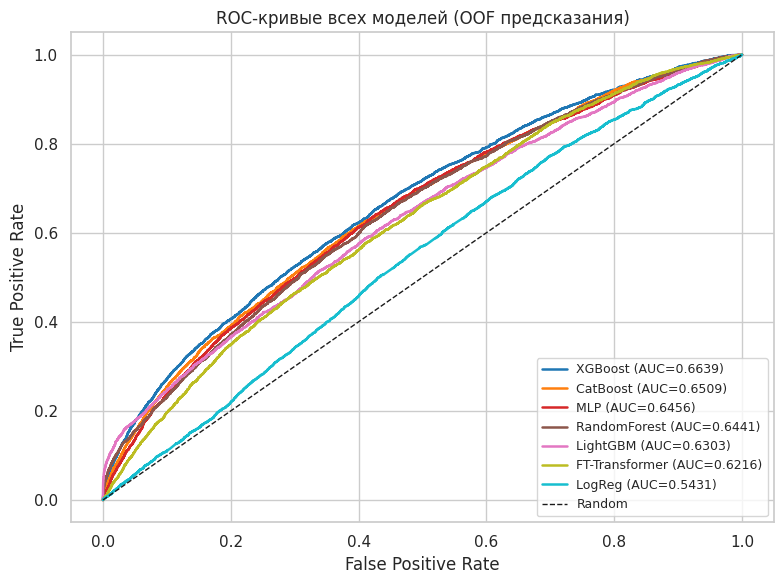

In [27]:
results_df = pd.DataFrame([
    {"Модель": name, "OOF AUC": f"{m['auc']:.5f}"}
    for name, m in sorted(MODEL_RESULTS.items(), key=lambda x: -x[1]["auc"])
])
print("=" * 40); print("ИТОГОВАЯ ТАБЛИЦА OOF AUC"); print("=" * 40)
display(results_df.style.background_gradient(cmap="RdYlGn", subset=["OOF AUC"])
        .set_caption("OOF AUC (5-fold Stratified CV)"))

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(MODEL_RESULTS)))
for (name, m), color in zip(sorted(MODEL_RESULTS.items(), key=lambda x: -x[1]["auc"]), colors):
    fpr, tpr, _ = roc_curve(y, m["oof"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={m['auc']:.4f})", color=color, lw=1.8)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC-кривые всех моделей (OOF предсказания)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()


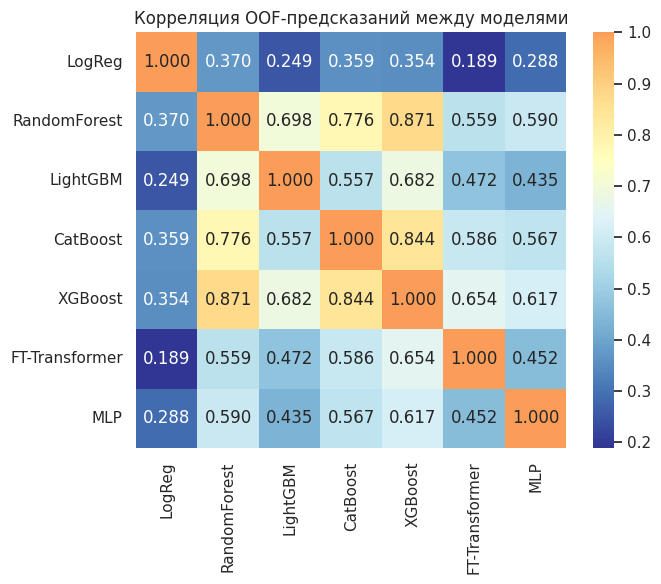

In [28]:
oof_matrix = pd.DataFrame({name: m["oof"] for name, m in MODEL_RESULTS.items()})
corr = oof_matrix.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlBu_r", center=0.75, ax=ax)
ax.set_title("Корреляция OOF-предсказаний между моделями")
plt.tight_layout(); plt.show()

## 15. Ансамблирование и финальный сабмит

In [30]:
print("=" * 50); print("Stacking (мета-модель: LogisticRegression)"); print("=" * 50)

STACK_MODELS = [name for name in MODEL_RESULTS
                if name not in ("RandomForest",) and MODEL_RESULTS[name]["auc"] > 0.55]
print(f"Модели для стекинга: {STACK_MODELS}")

meta_X_train = np.column_stack([MODEL_RESULTS[name]["oof"]  for name in STACK_MODELS])
meta_X_test  = np.column_stack([MODEL_RESULTS[name]["test"] for name in STACK_MODELS])

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_stack = np.zeros(len(meta_X_train)); test_stack = np.zeros(len(meta_X_test)); stack_scores = []

for fold, (tr, val) in enumerate(skf.split(meta_X_train, y)):
    meta_model = LogisticRegression(class_weight="balanced", C=1.0,
                                    max_iter=500, random_state=RANDOM_STATE)
    meta_model.fit(meta_X_train[tr], y[tr])
    vp = meta_model.predict_proba(meta_X_train[val])[:, 1]
    oof_stack[val] = vp
    test_stack += meta_model.predict_proba(meta_X_test)[:, 1] / N_FOLDS
    sc = roc_auc_score(y[val], vp)
    stack_scores.append(sc)
    print(f"  Fold {fold+1}: AUC={sc:.5f}")

stack_auc = roc_auc_score(y, oof_stack)
print(f"\nStacking OOF AUC : {stack_auc:.5f}")
print(f"Mean folds       : {np.mean(stack_scores):.5f} ± {np.std(stack_scores):.5f}")

final_meta = LogisticRegression(class_weight="balanced", C=1.0,
                                max_iter=500, random_state=RANDOM_STATE)
final_meta.fit(meta_X_train, y)
print("\nВеса базовых моделей в финальной мета-модели:")
for name, coef in zip(STACK_MODELS, final_meta.coef_[0]):
    print(f"  {name:20s}: {coef:+.4f}")

register("Stacking", oof_stack, test_stack, y)


Stacking (мета-модель: LogisticRegression)
Модели для стекинга: ['LightGBM', 'CatBoost', 'XGBoost', 'FT-Transformer', 'MLP']
  Fold 1: AUC=0.66690
  Fold 2: AUC=0.68211
  Fold 3: AUC=0.66013
  Fold 4: AUC=0.68330
  Fold 5: AUC=0.67733

Stacking OOF AUC : 0.67041
Mean folds       : 0.67396 ± 0.00901

Веса базовых моделей в финальной мета-модели:
  LightGBM            : +0.8303
  CatBoost            : +0.8230
  XGBoost             : +1.3778
  FT-Transformer      : +0.3599
  MLP                 : +0.9609
  [Stacking] OOF AUC = 0.67041


In [31]:
final_auc = MODEL_RESULTS["Stacking"]["auc"]
print("=" * 50)
print(f"Baseline (LogReg)      AUC = {BASELINE_AUC:.5f}")
print(f"Финальный ансамбль     AUC = {final_auc:.5f}")
print(f"Прирост к baseline     = +{final_auc - BASELINE_AUC:.5f}  "
      f"({(final_auc/BASELINE_AUC - 1)*100:.1f}%)")
print("=" * 50)


Baseline (LogReg)      AUC = 0.54313
Финальный ансамбль     AUC = 0.67041
Прирост к baseline     = +0.12728  (23.4%)


In [32]:
test_idx = pd.read_csv(f"{DATA_DIR}/test.csv", usecols=["index"], dtype=np.float32)["index"].astype(int).values

submission = pd.DataFrame({"index": test_idx, "score": MODEL_RESULTS["Stacking"]["test"]})
submission.to_csv(f"{SUBMIT_DIR}/submission_final.csv", index=False)
print(f"Сохранено: {SUBMIT_DIR}/submission_final.csv")
print(submission.head())


Сохранено: submissions/submission_final.csv
    index     score
0  194357  0.286537
1  313222  0.526182
2  321873  0.630552
3  118689  0.541822
4  342561  0.279871
